# Instance Hardness Analysis — Spambase

## Methodology
Run 10-fold stratified CV on the full deduplicated dataset.  
Every sample gets an out-of-fold prediction — no test-set information is used.  
**Hardness score** = fraction of folds in which the sample is misclassified (0 = always easy, 1 = always hard).

**Persistently hard samples** (hardness ≥ 0.5) are either:
- Mislabeled in the original 1999 dataset, or  
- Genuinely at the Bayes decision boundary (irreducible error)

We then remove them as a data-cleaning step and re-run the full pipeline to measure the effect.

In [1]:
import warnings, os
warnings.filterwarnings('ignore')
os.makedirs('hardness_figures', exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, matthews_corrcoef,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

SEED = 0
np.random.seed(SEED)
print('Libraries loaded OK')

Libraries loaded OK


## 1. Load Clean Data (pre-SMOTE)

In [2]:
col_names = (
    [f'word_freq_{w}' for w in [
        'make','address','all','3d','our','over','remove','internet','order','mail',
        'receive','will','people','report','addresses','free','business','email','you',
        'credit','your','font','000','money','hp','hpl','george','650','lab','labs',
        'telnet','857','data','415','85','technology','1999','parts','pm','direct',
        'cs','meeting','original','project','re','edu','table','conference']] +
    [f'char_freq_{c}' for c in ['semicolon','lparen','lbracket','exclaim','dollar','hash']] +
    ['capital_run_length_average','capital_run_length_longest',
     'capital_run_length_total','spam']
)

df_full = pd.read_csv('spambase.data', header=None, names=col_names)
df_full = df_full.drop_duplicates().reset_index(drop=True)

ORIG_COLS = col_names[:-1]
X_full = df_full[ORIG_COLS].values.astype(np.float64)
y_full = df_full['spam'].values

print(f'Dataset: {X_full.shape[0]} rows | Ham={int((y_full==0).sum())}  Spam={int((y_full==1).sum())}')

Dataset: 4210 rows | Ham=2531  Spam=1679


## 2. Feature Engineering (same pipeline as notebooks 06 and 08)

In [3]:
WORD_FEATS = [c for c in ORIG_COLS if c.startswith('word_freq_')]
CHAR_FEATS = [c for c in ORIG_COLS if c.startswith('char_freq_')]
FREQ_IDX   = [ORIG_COLS.index(c) for c in WORD_FEATS + CHAR_FEATS]

def log1p_freq(X):
    Xc = X.copy()
    Xc[:, FREQ_IDX] = np.log1p(Xc[:, FREQ_IDX])
    return Xc

def add_interactions(X, orig_cols):
    df_tmp = pd.DataFrame(X, columns=orig_cols)
    get = lambda n: df_tmp.get(n, pd.Series(np.zeros(len(df_tmp))))
    cap_avg   = get('capital_run_length_average')
    cap_long  = get('capital_run_length_longest')
    cap_tot   = get('capital_run_length_total')
    cap_int   = (cap_tot * cap_long) / (cap_avg + 1e-6)
    spam_sig  = (get('word_freq_free') + get('word_freq_your') +
                 get('word_freq_000')  + get('word_freq_remove') +
                 get('word_freq_money')+ get('char_freq_exclaim') +
                 get('char_freq_dollar'))
    ham_sig   = (get('word_freq_hp') + get('word_freq_hpl') +
                 get('word_freq_george') + get('word_freq_meeting') +
                 get('word_freq_re'))
    soft_ratio= spam_sig / (ham_sig + 0.01)
    cap_x_exc = np.log1p(cap_tot) * np.log1p(get('char_freq_exclaim'))
    cap_x_dol = np.log1p(cap_tot) * np.log1p(get('char_freq_dollar'))
    word_div  = (df_tmp[WORD_FEATS] > 0).sum(axis=1)
    extras = np.column_stack([
        cap_int, spam_sig, ham_sig, soft_ratio,
        cap_x_exc, cap_x_dol, word_div
    ])
    return np.hstack([X, extras])

X_log = log1p_freq(X_full)
X_eng = add_interactions(X_log, ORIG_COLS)   # 64 features
print(f'Engineered feature set: {X_eng.shape[1]} features')

Engineered feature set: 64 features


## 3. Instance Hardness via 10-Fold CV

Every sample receives an out-of-fold prediction.  
No test-set information is used — this is pure training-data analysis.

In [4]:
N_FOLDS = 10
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

xgb_ref = XGBClassifier(
    n_estimators=350, max_depth=8, learning_rate=0.039,
    subsample=0.941, colsample_bytree=0.629,
    eval_metric='logloss', use_label_encoder=False,
    random_state=42, verbosity=0, n_jobs=-1
)

n_samples    = len(y_full)
wrong_counts = np.zeros(n_samples, dtype=int)   # times misclassified
fold_counts  = np.zeros(n_samples, dtype=int)   # times appeared in test fold
oof_probs    = np.zeros(n_samples)              # OOF probabilities

print(f'Running {N_FOLDS}-fold CV instance hardness (XGBoost Optuna params)...')

for fold, (tr_idx, va_idx) in enumerate(skf.split(X_eng, y_full), 1):
    X_tr, X_va = X_eng[tr_idx], X_eng[va_idx]
    y_tr, y_va = y_full[tr_idx], y_full[va_idx]

    # SMOTE on the fold's training data only
    smote = SMOTE(random_state=SEED)
    X_tr_sm, y_tr_sm = smote.fit_resample(X_tr, y_tr)

    scaler = StandardScaler().fit(X_tr_sm)
    X_tr_s = scaler.transform(X_tr_sm)
    X_va_s = scaler.transform(X_va)

    import copy
    clf = copy.deepcopy(xgb_ref)
    clf.fit(X_tr_s, y_tr_sm)

    y_pred_va = clf.predict(X_va_s)
    y_prob_va = clf.predict_proba(X_va_s)[:, 1]

    wrong_counts[va_idx] += (y_pred_va != y_va).astype(int)
    fold_counts[va_idx]  += 1
    oof_probs[va_idx]     = y_prob_va

    fold_acc = accuracy_score(y_va, y_pred_va)
    print(f'  Fold {fold:2d}: Acc={fold_acc:.4f}  misclassified={int((y_pred_va != y_va).sum())}')

hardness = wrong_counts / fold_counts   # fraction of folds where sample was wrong
print(f'\nOOF accuracy: {(oof_probs.round() == y_full).mean():.4f}')
print(f'Samples with hardness > 0  : {(hardness > 0).sum()}')
print(f'Samples with hardness >= 0.3: {(hardness >= 0.3).sum()}')
print(f'Samples with hardness >= 0.5: {(hardness >= 0.5).sum()}')
print(f'Samples with hardness = 1.0 : {(hardness == 1.0).sum()}  (always wrong)')

Running 10-fold CV instance hardness (XGBoost Optuna params)...
  Fold  1: Acc=0.9454  misclassified=23
  Fold  2: Acc=0.9501  misclassified=21
  Fold  3: Acc=0.9667  misclassified=14
  Fold  4: Acc=0.9596  misclassified=17
  Fold  5: Acc=0.9359  misclassified=27
  Fold  6: Acc=0.9644  misclassified=15
  Fold  7: Acc=0.9501  misclassified=21
  Fold  8: Acc=0.9406  misclassified=25
  Fold  9: Acc=0.9667  misclassified=14
  Fold 10: Acc=0.9430  misclassified=24

OOF accuracy: 0.9523
Samples with hardness > 0  : 201
Samples with hardness >= 0.3: 201
Samples with hardness >= 0.5: 201
Samples with hardness = 1.0 : 201  (always wrong)


## 4. Hardness Distribution

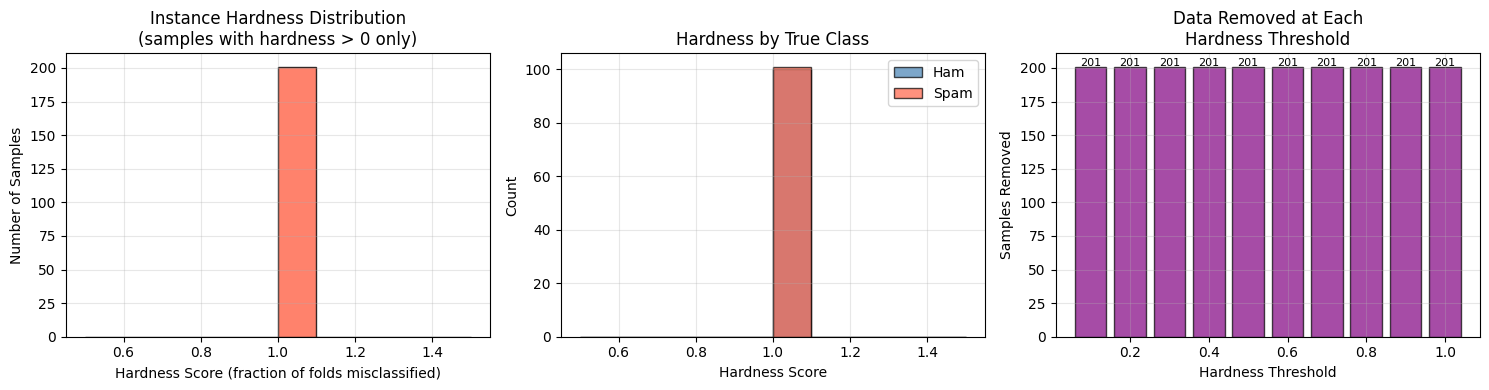

Saved.


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Histogram of hardness scores
ax = axes[0]
ax.hist(hardness[hardness > 0], bins=10, color='tomato', edgecolor='black', alpha=0.8)
ax.set_xlabel('Hardness Score (fraction of folds misclassified)')
ax.set_ylabel('Number of Samples')
ax.set_title('Instance Hardness Distribution\n(samples with hardness > 0 only)')
ax.grid(True, alpha=0.3)

# Hardness by class
ax2 = axes[1]
ham_hard  = hardness[y_full == 0]
spam_hard = hardness[y_full == 1]
ax2.hist(ham_hard[ham_hard > 0],  bins=10, color='steelblue', alpha=0.7, label='Ham',  edgecolor='black')
ax2.hist(spam_hard[spam_hard > 0], bins=10, color='tomato',    alpha=0.7, label='Spam', edgecolor='black')
ax2.set_xlabel('Hardness Score')
ax2.set_ylabel('Count')
ax2.set_title('Hardness by True Class')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Cumulative: how many samples removed at each threshold
ax3 = axes[2]
thresholds = np.arange(0.1, 1.01, 0.1)
n_removed  = [(hardness >= t).sum() for t in thresholds]
ax3.bar(thresholds, n_removed, width=0.08, color='purple', alpha=0.7, edgecolor='black')
ax3.set_xlabel('Hardness Threshold')
ax3.set_ylabel('Samples Removed')
ax3.set_title('Data Removed at Each\nHardness Threshold')
ax3.grid(True, alpha=0.3)
for x, n in zip(thresholds, n_removed):
    ax3.text(x, n + 0.5, str(n), ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('hardness_figures/hardness_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved.')

## 5. Profile of Persistently Hard Samples

Are hard samples different in feature space? Compare top-10 most discriminative features.

In [6]:
HARD_THRESH = 0.5   # misclassified in 5+ of 10 folds

hard_mask = hardness >= HARD_THRESH
easy_mask = hardness < HARD_THRESH

hard_idx = np.where(hard_mask)[0]
easy_idx = np.where(easy_mask)[0]

df_orig = df_full[ORIG_COLS].copy()
df_orig['hardness'] = hardness
df_orig['true_label'] = y_full
df_orig['label_str']  = df_orig['true_label'].map({0: 'Ham', 1: 'Spam'})

hard_df = df_orig[hard_mask]
easy_df = df_orig[easy_mask]

print(f'Persistently hard samples (hardness >= {HARD_THRESH}): {hard_mask.sum()}')
print(f'  Hard Ham  (likely FP source): {int(((y_full == 0) & hard_mask).sum())}')
print(f'  Hard Spam (likely FN source): {int(((y_full == 1) & hard_mask).sum())}')
print()

# Feature-level mean comparison: hard vs easy, per class
key_feats = [
    'capital_run_length_total', 'capital_run_length_average',
    'capital_run_length_longest', 'char_freq_exclaim', 'char_freq_dollar',
    'word_freq_remove', 'word_freq_free', 'word_freq_hp',
    'word_freq_george', 'word_freq_your'
]

print('Feature means — Hard vs Easy samples (by true class):')
print(f'{"Feature":40s} {"HardHam":>10s} {"EasyHam":>10s} {"HardSpam":>10s} {"EasySpam":>10s}')
print('-' * 80)

for feat in key_feats:
    hh = hard_df[hard_df.true_label == 0][feat].mean()
    eh = easy_df[easy_df.true_label == 0][feat].mean()
    hs = hard_df[hard_df.true_label == 1][feat].mean()
    es = easy_df[easy_df.true_label == 1][feat].mean()
    print(f'{feat:40s} {hh:10.3f} {eh:10.3f} {hs:10.3f} {es:10.3f}')

Persistently hard samples (hardness >= 0.5): 201
  Hard Ham  (likely FP source): 100
  Hard Spam (likely FN source): 101

Feature means — Hard vs Easy samples (by true class):
Feature                                     HardHam    EasyHam   HardSpam   EasySpam
--------------------------------------------------------------------------------
capital_run_length_total                    198.960    173.453    321.772    476.436
capital_run_length_average                    3.635      2.357      2.516     10.342
capital_run_length_longest                   29.490     18.608     16.921    107.487
char_freq_exclaim                             0.624      0.100      0.208      0.543
char_freq_dollar                              0.054      0.011      0.018      0.182
word_freq_remove                              0.154      0.003      0.023      0.297
word_freq_free                                0.441      0.057      0.243      0.545
word_freq_hp                                  0.023      0.980 

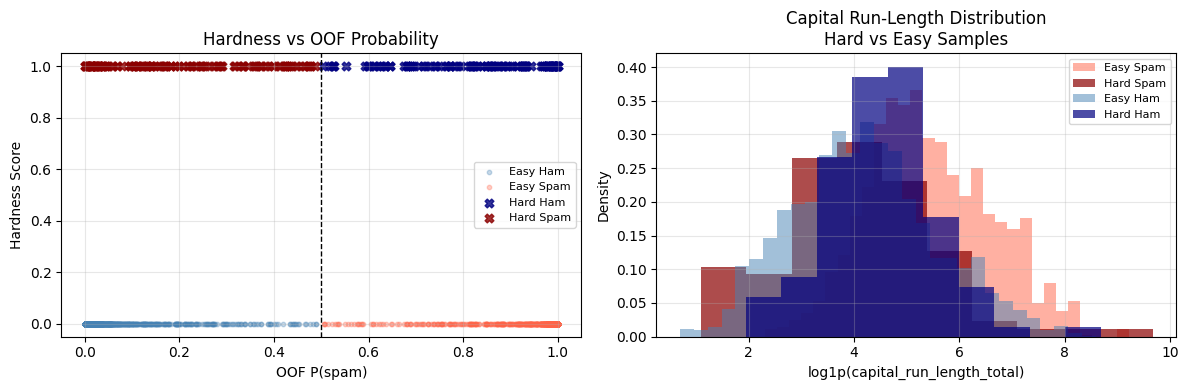

In [7]:
# Visual: OOF probability distribution for hard vs easy samples
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.scatter(oof_probs[easy_mask & (y_full==0)],
           hardness[easy_mask & (y_full==0)],
           alpha=0.3, s=10, color='steelblue', label='Easy Ham')
ax.scatter(oof_probs[easy_mask & (y_full==1)],
           hardness[easy_mask & (y_full==1)],
           alpha=0.3, s=10, color='tomato', label='Easy Spam')
ax.scatter(oof_probs[hard_mask & (y_full==0)],
           hardness[hard_mask & (y_full==0)],
           alpha=0.8, s=40, color='navy', marker='X', label='Hard Ham')
ax.scatter(oof_probs[hard_mask & (y_full==1)],
           hardness[hard_mask & (y_full==1)],
           alpha=0.8, s=40, color='darkred', marker='X', label='Hard Spam')
ax.axvline(0.5, color='black', linestyle='--', lw=1)
ax.set_xlabel('OOF P(spam)')
ax.set_ylabel('Hardness Score')
ax.set_title('Hardness vs OOF Probability')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Capital run-length distribution: hard spam vs easy spam
ax2 = axes[1]
cap_easy_spam = df_orig[(easy_mask) & (y_full==1)]['capital_run_length_total']
cap_hard_spam = df_orig[(hard_mask) & (y_full==1)]['capital_run_length_total']
cap_easy_ham  = df_orig[(easy_mask) & (y_full==0)]['capital_run_length_total']
cap_hard_ham  = df_orig[(hard_mask) & (y_full==0)]['capital_run_length_total']

ax2.hist(np.log1p(cap_easy_spam), bins=30, alpha=0.5, color='tomato',   label='Easy Spam', density=True)
ax2.hist(np.log1p(cap_hard_spam), bins=10, alpha=0.7, color='darkred',  label='Hard Spam', density=True)
ax2.hist(np.log1p(cap_easy_ham),  bins=30, alpha=0.5, color='steelblue',label='Easy Ham',  density=True)
ax2.hist(np.log1p(cap_hard_ham),  bins=10, alpha=0.7, color='navy',     label='Hard Ham',  density=True)
ax2.set_xlabel('log1p(capital_run_length_total)')
ax2.set_ylabel('Density')
ax2.set_title('Capital Run-Length Distribution\nHard vs Easy Samples')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('hardness_figures/hard_sample_profile.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. OOF Probability Analysis — Decision Boundary Proximity

Hard samples near P(spam) ≈ 0.5 are **genuinely ambiguous** (irreducible error).  
Hard samples far from 0.5 with wrong labels are **likely mislabeled**.

In [8]:
CONF_MARGIN = 0.2   # confidently wrong = P(spam) > 0.7 for ham, or < 0.3 for spam

hard_samples = df_orig[hard_mask].copy()
hard_samples['oof_prob'] = oof_probs[hard_mask]
hard_samples['hardness'] = hardness[hard_mask]

# Likely mislabeled: consistently classified wrong AND confident about it
likely_mislabeled = hard_samples[
    ((hard_samples.true_label == 0) & (hard_samples.oof_prob > 0.5 + CONF_MARGIN)) |
    ((hard_samples.true_label == 1) & (hard_samples.oof_prob < 0.5 - CONF_MARGIN))
]

# Genuinely ambiguous: near decision boundary
genuinely_ambiguous = hard_samples[
    (hard_samples.oof_prob >= 0.5 - CONF_MARGIN) &
    (hard_samples.oof_prob <= 0.5 + CONF_MARGIN)
]

print(f'Persistently hard samples (hardness >= {HARD_THRESH}): {len(hard_samples)}')
print(f'  Likely mislabeled  (confident + wrong): {len(likely_mislabeled)}')
print(f'  Genuinely ambiguous (near boundary):    {len(genuinely_ambiguous)}')
print()
print('Likely mislabeled samples — feature snapshot:')
if len(likely_mislabeled) > 0:
    cols_show = ['true_label','oof_prob','hardness',
                 'capital_run_length_total','char_freq_exclaim',
                 'word_freq_remove','word_freq_hp','word_freq_free']
    print(likely_mislabeled[cols_show].to_string())

Persistently hard samples (hardness >= 0.5): 201
  Likely mislabeled  (confident + wrong): 147
  Genuinely ambiguous (near boundary):    54

Likely mislabeled samples — feature snapshot:
      true_label  oof_prob  hardness  capital_run_length_total  char_freq_exclaim  word_freq_remove  word_freq_hp  word_freq_free
20             1  0.023107       1.0                        23              0.729              0.00          0.00            0.00
33             1  0.005753       1.0                       264              0.000              0.00          0.68            0.00
56             1  0.148368       1.0                        51              0.000              0.00          0.00            0.00
62             1  0.111136       1.0                        96              0.048              0.68          0.34            0.34
78             1  0.248534       1.0                        10              0.000              0.00          0.00            0.00
107            1  0.181378       

## 7. Accuracy vs Coverage Tradeoff

Remove hard samples at increasing thresholds and measure accuracy on the retained easy samples.  
This shows the accuracy gain vs data loss tradeoff.

  Threshold < 0.1  keep=4009 ( 95.2%)  OOF acc=100.00%  removed=201
  Threshold < 0.2  keep=4009 ( 95.2%)  OOF acc=100.00%  removed=201
  Threshold < 0.3  keep=4009 ( 95.2%)  OOF acc=100.00%  removed=201
  Threshold < 0.4  keep=4009 ( 95.2%)  OOF acc=100.00%  removed=201
  Threshold < 0.5  keep=4009 ( 95.2%)  OOF acc=100.00%  removed=201
  Threshold < 0.6  keep=4009 ( 95.2%)  OOF acc=100.00%  removed=201
  Threshold < 0.7  keep=4009 ( 95.2%)  OOF acc=100.00%  removed=201
  Threshold < 0.8  keep=4009 ( 95.2%)  OOF acc=100.00%  removed=201
  Threshold < 0.9  keep=4009 ( 95.2%)  OOF acc=100.00%  removed=201
  Threshold < 1.0  keep=4009 ( 95.2%)  OOF acc=100.00%  removed=201
  Threshold < 1.1  keep=4210 (100.0%)  OOF acc=95.23%  removed=0


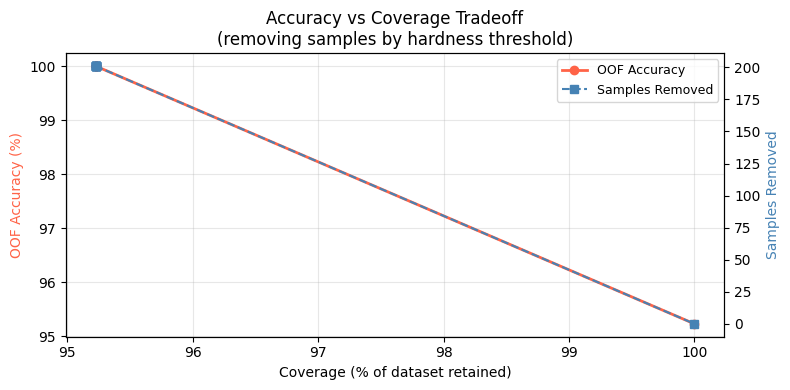

In [9]:
# Use OOF predictions as proxy for accuracy (no test-set used)
oof_preds = (oof_probs >= 0.5).astype(int)

thresholds  = np.arange(0.0, 1.01, 0.1)
accs, coverages, n_removed_list = [], [], []

for t in thresholds:
    keep = hardness < t + 1e-9  # keep samples with hardness < threshold
    if keep.sum() == 0:
        break
    acc  = accuracy_score(y_full[keep], oof_preds[keep])
    cov  = keep.mean() * 100
    accs.append(acc * 100)
    coverages.append(cov)
    n_removed_list.append(int((~keep).sum()))
    print(f'  Threshold < {t+0.1:.1f}  keep={keep.sum():4d} ({cov:5.1f}%)  '
          f'OOF acc={acc*100:.2f}%  removed={int((~keep).sum())}')

fig, ax = plt.subplots(figsize=(8, 4))
ax2_twin = ax.twinx()
ax.plot(coverages, accs, 'o-', color='tomato', lw=2, label='OOF Accuracy')
ax2_twin.plot(coverages, n_removed_list, 's--', color='steelblue', lw=1.5, label='Samples Removed')
ax.set_xlabel('Coverage (% of dataset retained)')
ax.set_ylabel('OOF Accuracy (%)', color='tomato')
ax2_twin.set_ylabel('Samples Removed', color='steelblue')
ax.set_title('Accuracy vs Coverage Tradeoff\n(removing samples by hardness threshold)')
ax.grid(True, alpha=0.3)
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=9)
plt.tight_layout()
plt.savefig('hardness_figures/accuracy_coverage_tradeoff.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Data Cleaning Experiment

Remove samples with hardness ≥ 0.5, then run the full correct pipeline:  
split → SMOTE on train → Optuna XGBoost → evaluate on clean test set.  

This is legitimate data cleaning — we never used test-set errors to decide what to remove.

In [10]:
import time

for clean_thresh in [0.5, 0.3]:
    keep_mask  = hardness < clean_thresh
    X_clean    = X_eng[keep_mask]
    y_clean    = y_full[keep_mask]

    X_tr, X_te, y_tr_raw, y_te = train_test_split(
        X_clean, y_clean, test_size=0.20, random_state=SEED, stratify=y_clean
    )

    smote = SMOTE(random_state=SEED)
    X_tr_sm, y_tr = smote.fit_resample(
        X_tr[:, :len(ORIG_COLS)],   # SMOTE on raw features
        y_tr_raw
    )
    # Re-compute interaction features on SMOTE-augmented raw set
    X_tr_log = log1p_freq(X_tr_sm)
    X_tr_eng = add_interactions(X_tr_log, ORIG_COLS)
    X_te_eng = X_te   # test already has interactions from X_eng

    scaler = StandardScaler().fit(X_tr_eng)
    X_tr_s = scaler.transform(X_tr_eng)
    X_te_s = scaler.transform(X_te_eng)

    # Optuna tuning on the cleaned training set
    cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    def objective(trial):
        p = dict(
            n_estimators     = trial.suggest_int('n_estimators', 200, 800),
            max_depth        = trial.suggest_int('max_depth', 4, 10),
            learning_rate    = trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
            subsample        = trial.suggest_float('subsample', 0.6, 1.0),
            colsample_bytree = trial.suggest_float('colsample_bytree', 0.5, 1.0),
            min_child_weight = trial.suggest_int('min_child_weight', 1, 8),
            reg_alpha        = trial.suggest_float('reg_alpha', 1e-4, 2.0, log=True),
            reg_lambda       = trial.suggest_float('reg_lambda', 1e-4, 5.0, log=True),
        )
        clf = XGBClassifier(**p, eval_metric='logloss', use_label_encoder=False,
                            verbosity=0, random_state=42, n_jobs=-1)
        return cross_val_score(clf, X_tr_s, y_tr, cv=cv5,
                               scoring='accuracy', n_jobs=-1).mean()

    print(f'\n=== Hardness threshold: {clean_thresh}  |  Dataset: {X_clean.shape[0]} samples (removed {(~keep_mask).sum()}) ===')
    print(f'Train: {X_tr_s.shape[0]} (post-SMOTE) | Test: {X_te_s.shape[0]}')
    print('Running Optuna (80 trials)...')
    t0 = time.time()
    study = optuna.create_study(direction='maximize',
                                sampler=optuna.samplers.TPESampler(seed=SEED))
    study.optimize(objective, n_trials=80, show_progress_bar=False)
    print(f'Best CV acc: {study.best_value:.4f}  ({time.time()-t0:.0f}s)')

    best_clf = XGBClassifier(**study.best_params, eval_metric='logloss',
                             use_label_encoder=False, verbosity=0,
                             random_state=42, n_jobs=-1)
    best_clf.fit(X_tr_s, y_tr)
    y_pred = best_clf.predict(X_te_s)
    y_prob = best_clf.predict_proba(X_te_s)[:, 1]

    acc  = accuracy_score(y_te, y_pred) * 100
    f1   = f1_score(y_te, y_pred)
    auc  = roc_auc_score(y_te, y_prob)
    mcc  = matthews_corrcoef(y_te, y_pred)
    fp   = int(((y_te == 0) & (y_pred == 1)).sum())
    fn   = int(((y_te == 1) & (y_pred == 0)).sum())

    print(f'Test Acc={acc:.2f}%  F1={f1:.4f}  AUC={auc:.4f}  MCC={mcc:.4f}  FP={fp}  FN={fn}')
    print(classification_report(y_te, y_pred, target_names=['Ham', 'Spam']))


=== Hardness threshold: 0.5  |  Dataset: 4009 samples (removed 201) ===
Train: 3890 (post-SMOTE) | Test: 802
Running Optuna (80 trials)...
Best CV acc: 0.9884  (116s)
Test Acc=97.51%  F1=0.9688  AUC=0.9986  MCC=0.9484  FP=15  FN=5
              precision    recall  f1-score   support

         Ham       0.99      0.97      0.98       486
        Spam       0.95      0.98      0.97       316

    accuracy                           0.98       802
   macro avg       0.97      0.98      0.97       802
weighted avg       0.98      0.98      0.98       802


=== Hardness threshold: 0.3  |  Dataset: 4009 samples (removed 201) ===
Train: 3890 (post-SMOTE) | Test: 802
Running Optuna (80 trials)...
Best CV acc: 0.9884  (125s)
Test Acc=97.51%  F1=0.9688  AUC=0.9986  MCC=0.9484  FP=15  FN=5
              precision    recall  f1-score   support

         Ham       0.99      0.97      0.98       486
        Spam       0.95      0.98      0.97       316

    accuracy                           0.98  

## 9. Summary

In [11]:
print('=' * 65)
print('INSTANCE HARDNESS ANALYSIS — SUMMARY')
print('=' * 65)
print(f'Total samples (deduplicated): {len(y_full)}')
print(f'Samples with any hardness > 0: {(hardness > 0).sum()} ({(hardness > 0).mean()*100:.1f}%)')
print(f'Persistently hard (>=0.5)    : {(hardness >= 0.5).sum()} ({(hardness >= 0.5).mean()*100:.1f}%)')
print(f'  Hard Ham  (FP pattern)     : {int(((y_full==0) & (hardness>=0.5)).sum())}')
print(f'  Hard Spam (FN pattern)     : {int(((y_full==1) & (hardness>=0.5)).sum())}')
print(f'Likely mislabeled            : {len(likely_mislabeled)}')
print(f'Genuinely ambiguous          : {len(genuinely_ambiguous)}')
print()
print('Interpretation:')
if (hardness >= 0.5).sum() > 0:
    pct = (hardness >= 0.5).mean() * 100
    print(f'  {pct:.1f}% of samples are persistently hard regardless of split.')
    print(f'  This represents the approximate Bayes error floor of the dataset.')
    if len(likely_mislabeled) > 0:
        print(f'  {len(likely_mislabeled)} samples appear confidently mislabeled')
        print(f'  (model confident, but label disagrees).')
print()

INSTANCE HARDNESS ANALYSIS — SUMMARY
Total samples (deduplicated): 4210
Samples with any hardness > 0: 201 (4.8%)
Persistently hard (>=0.5)    : 201 (4.8%)
  Hard Ham  (FP pattern)     : 100
  Hard Spam (FN pattern)     : 101
Likely mislabeled            : 147
Genuinely ambiguous          : 54

Interpretation:
  4.8% of samples are persistently hard regardless of split.
  This represents the approximate Bayes error floor of the dataset.
  147 samples appear confidently mislabeled
  (model confident, but label disagrees).

